In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision.models import efficientnet_b0
import timm
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import pandas as pd

BASE   = Path(r"C:\Users\npd20\Downloads\ĐACN_v2")
MODELS = BASE / "models"
FIGS   = BASE / "reports" / "figures"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SCORES = sorted(
    [f"{i}.{d}" for i in range(0, 10) for d in [0, 3, 5, 8]] + ["10"],
    key=lambda x: float(x)
)
idx2label = {i: s for i, s in enumerate(SCORES)}
label2idx = {s: i for i, s in idx2label.items()}

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
deit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

print(f"Device: {DEVICE}")

Device: cuda


#  Load 2 models + setup Grad-CAM:

In [2]:
# Load EfficientNet_B0
effb0 = efficientnet_b0(weights=None)
effb0.classifier[1] = nn.Linear(effb0.classifier[1].in_features, 41)
effb0.load_state_dict(torch.load(MODELS / "EfficientNet_B0.pth", map_location=DEVICE))
effb0 = effb0.to(DEVICE).eval()

# Load DeiT
deit = timm.create_model("deit_tiny_patch16_224", pretrained=False, num_classes=41)
deit.load_state_dict(torch.load(MODELS / "DeiT_Tiny.pth", map_location=DEVICE))
deit = deit.to(DEVICE).eval()

print("Models loaded ✅")

# Grad-CAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(1).item()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.squeeze().cpu().numpy(), idx2label[class_idx]

# Setup Grad-CAM cho EfficientNet_B0
# Target layer: last conv block
gradcam_effb0 = GradCAM(effb0, effb0.features[-1])

print("GradCAM ready ✅")

Models loaded ✅
GradCAM ready ✅


#  Visualize Grad-CAM trên external test set:

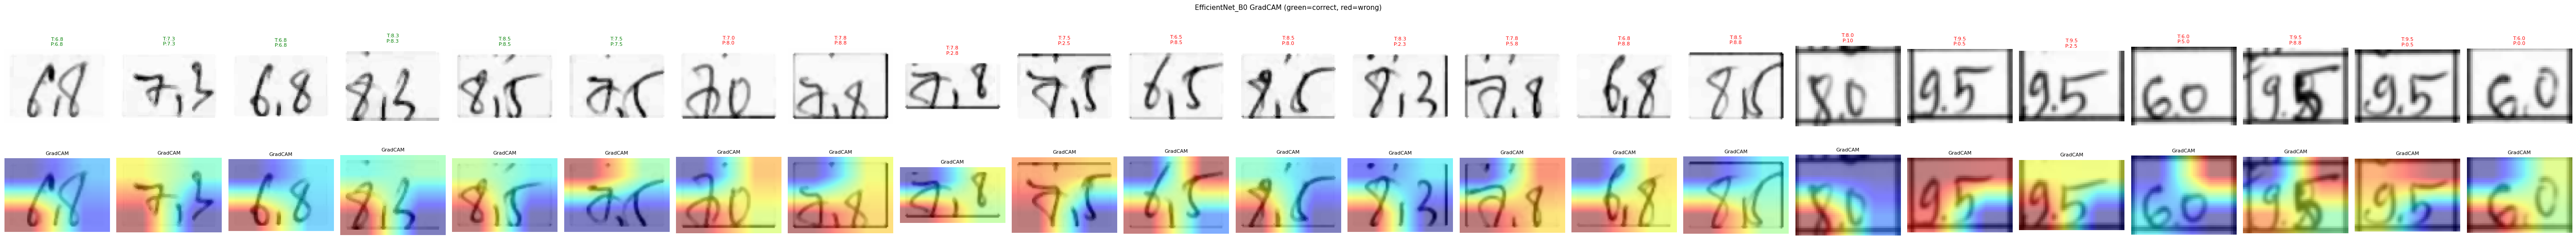

Correct: 6 | Wrong: 17 | Total shown: 23


In [5]:
def show_gradcam(img_path, model, gradcam, transform):
    img_orig = Image.open(img_path).convert("RGB")
    tensor = transform(img_orig).unsqueeze(0).to(DEVICE)
    
    cam, pred_label = gradcam.generate(tensor)
    
    cam_resized = np.array(Image.fromarray(cam).resize(img_orig.size, Image.BILINEAR))
    heatmap = cm.jet(cam_resized)[:, :, :3]
    img_arr = np.array(img_orig.convert("RGB")) / 255.0
    overlay = np.clip(0.5 * img_arr + 0.5 * heatmap, 0, 1)
    
    return img_orig, overlay, pred_label

# Load external test
df1 = pd.read_csv(BASE / "Test_Phieu_01" / "external_test_labels.csv")
df2 = pd.read_csv(BASE / "Test_Phieu_02" / "external_test_labels.csv")
df_ext = pd.concat([df1, df2]).dropna(subset=["label"]).reset_index(drop=True)
df_ext["label_str"] = df_ext["label"].apply(lambda x: "10" if str(x)=="10.0" else str(x))

# Predict EfficientNet_B0
with torch.no_grad():
    preds = []
    for _, row in df_ext.iterrows():
        tensor = val_transform(Image.open(row["image_path"]).convert("RGB")).unsqueeze(0).to(DEVICE)
        pred = idx2label[effb0(tensor).argmax(1).item()]
        preds.append(pred)
df_ext["pred"] = preds

# Lấy 6 đúng + tất cả sai
df_correct = df_ext[df_ext["pred"] == df_ext["label_str"]].head(6)
df_wrong   = df_ext[df_ext["pred"] != df_ext["label_str"]]
df_show    = pd.concat([df_correct, df_wrong]).reset_index(drop=True)

n = len(df_show)
fig, axes = plt.subplots(2, n, figsize=(n*2.5, 6))

for i, (_, row) in enumerate(df_show.iterrows()):
    img_orig, overlay, pred = show_gradcam(
        row["image_path"], effb0, gradcam_effb0, val_transform
    )
    is_correct = row["pred"] == row["label_str"]
    color = "green" if is_correct else "red"

    axes[0][i].imshow(img_orig, cmap="gray")
    axes[0][i].set_title(f"T:{row['label_str']}\nP:{pred}", fontsize=8, color=color)
    axes[0][i].axis("off")

    axes[1][i].imshow(overlay)
    axes[1][i].set_title("GradCAM", fontsize=8)
    axes[1][i].axis("off")

plt.suptitle("EfficientNet_B0 GradCAM (green=correct, red=wrong)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGS / "gradcam_effb0.png", dpi=100)
plt.show()

print(f"Correct: {len(df_correct)} | Wrong: {len(df_wrong)} | Total shown: {n}")